230063B
Athukorala U.R.

In [1]:
!pip install opencv-python

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Q1 — Piecewise intensity transform

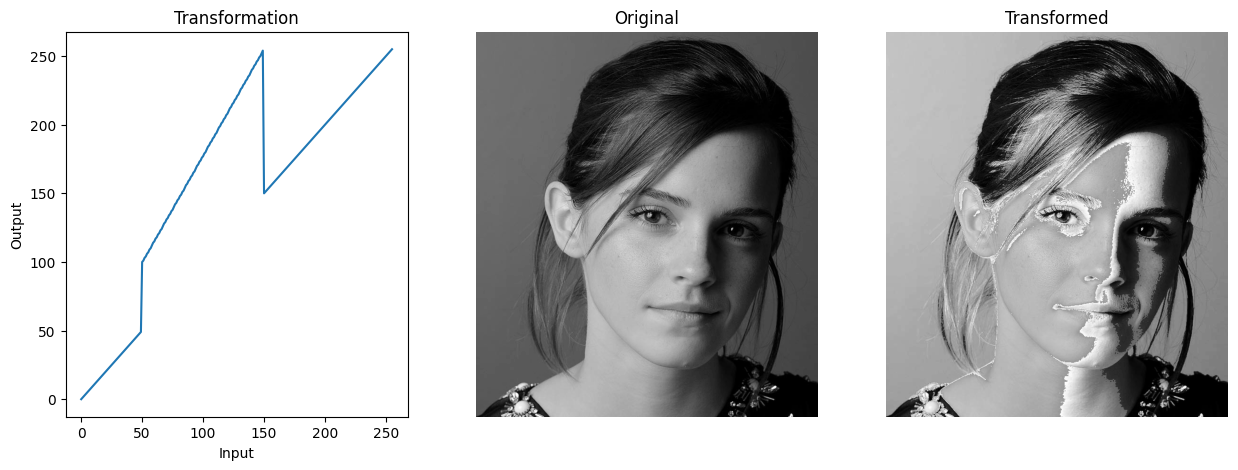

In [5]:
def intensity_transform(im, segments):
    lut = np.zeros(256, dtype=np.uint8)
    for (x0, y0), (x1, y1) in segments:
        xs = np.arange(x0, x1 + 1)
        ys = y0 if x1 == x0 else y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
        lut[x0:x1 + 1] = np.clip(ys, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)

img = cv2.imread('emma.png', cv2.IMREAD_GRAYSCALE)
assert img is not None, "check the filename/path"

segments = [((0, 0), (49, 49)), ((50, 100), (149, 254)), ((150, 150), (255, 255))]
transformed = intensity_transform(img, segments)

# Plot the transformation curve
lut_plot = np.zeros(256, dtype=np.uint8)
for (x0, y0), (x1, y1) in segments:
    xs = np.arange(x0, x1 + 1)
    ys = y0 if x1 == x0 else y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
    lut_plot[x0:x1 + 1] = np.clip(ys, 0, 255)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(range(256), lut_plot); ax[0].set_title("Transformation"); ax[0].set_xlabel("Input"); ax[0].set_ylabel("Output")
ax[1].imshow(img, cmap='gray'); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(transformed, cmap='gray'); ax[2].set_title("Transformed"); ax[2].axis('off')
plt.show()

the jump at x=50 forces mid-range shadows to leap to a brighter value, keeping the darker values upto x=50 at the normal intensity range while the second segment stretches midtones for more contrast; the drop at x=150 recompresses bright details to the normal level.We can see that the contrast between left and right sides of the face and the contrast near the hairline compared to skin is increased.

Q2 — Accentuate white/gray matter

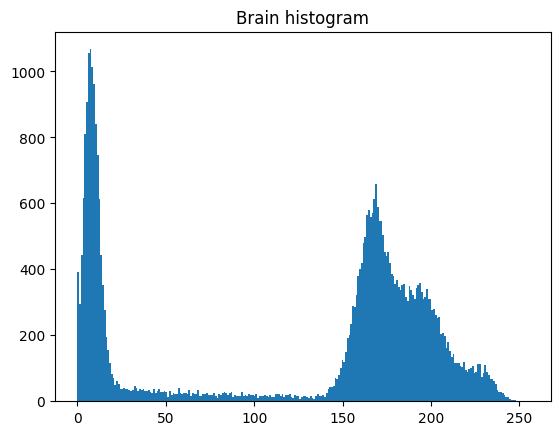

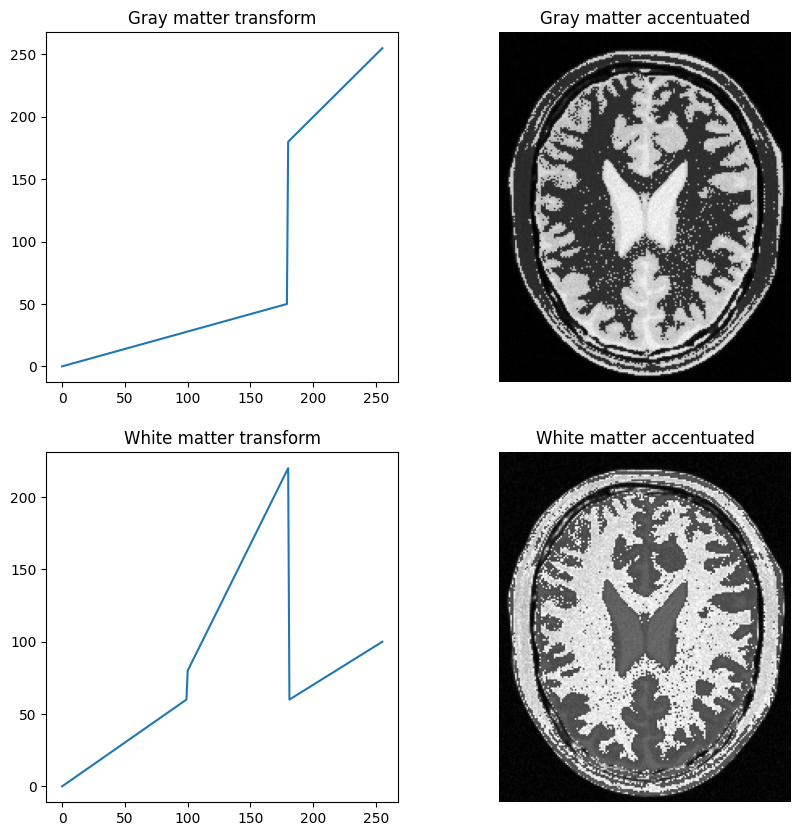

In [16]:
brain = cv2.imread('brain.jpeg', cv2.IMREAD_GRAYSCALE)
assert brain is not None

plt.hist(brain.ravel(), bins=256, range=(0,255))
plt.title("Brain histogram"); plt.show()

# (a) Accentuate gray matter (bright range ~180-255)
gray_segments = [((0,0),(179,50)), ((180,180),(255,255))]
gray_boost = intensity_transform(brain, gray_segments)

# (b) Accentuate white matter (mid range ~100-180)
white_segments = [((0,0),(99,60)), ((100,80),(180,220)), ((181,60),(255,100))]
white_boost = intensity_transform(brain, white_segments)

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].plot(range(256), [
    (v*50/179 if v<=179 else
     180+(v-180)*(255-180)/(255-180))
    for v in range(256)
])
ax[0,0].set_title("Gray matter transform")
ax[0,1].imshow(gray_boost, cmap='gray'); ax[0,1].set_title("Gray matter accentuated"); ax[0,1].axis('off')

ax[1,0].plot(range(256), [
    (v*60/99 if v<=99 else
     (80+(v-100)*140/80 if v<=180 else
      60+(v-181)*40/74))
    for v in range(256)
])
ax[1,0].set_title("White matter transform")
ax[1,1].imshow(white_boost, cmap='gray'); ax[1,1].set_title("White matter accentuated"); ax[1,1].axis('off')
plt.show()

Gray matter transform: Below x=180, all intensities are compressed down into a dim 0–50 band — this flattens the skull, background, and white matter tracts into near uniform darkness, removing their visual competition. From x=180 onward, the curve holds an identity slope, leaving the brightest tissue.
White matter transform: The low range (0–99) is compressed into a dim 0–60 band, suppressing it. The critical move happens in the 100–180 range, where the white matter gets stretched out into a much wider 80–220 output band, sharply increasing local contrast. Everything above 180 then drops and recompresses into a narrow 60–100 output range, which is a deliberate discontinuity: it suppresses the already-bright tissue so it doesn't visually dominate, letting the now-stretched white matter stand out instead.


In [ ]:
Q3 — Gamma correction

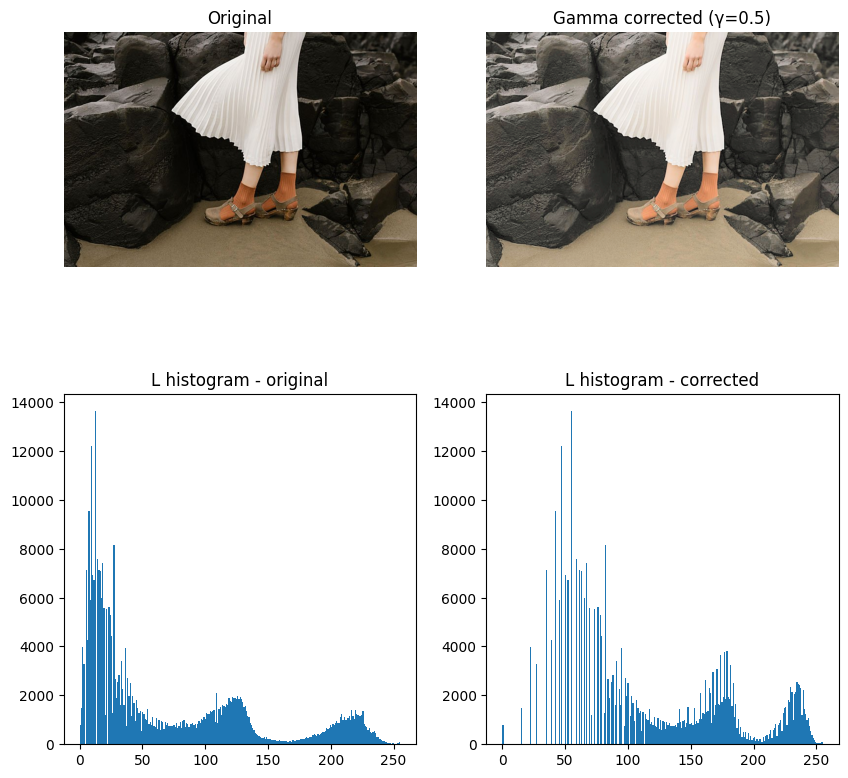

In [25]:
img3 = cv2.imread('whiteskirt.jpeg')
assert img3 is not None

lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

gamma = 0.5
L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = L_gamma.astype(np.uint8)

lab_corrected = cv2.merge([L_gamma, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, ax = plt.subplots(2, 2, figsize=(10,10))
ax[0,0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); ax[0,0].set_title("Original"); ax[0,0].axis('off')
ax[0,1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB)); ax[0,1].set_title(f"Gamma corrected (γ={gamma})"); ax[0,1].axis('off')
ax[1,0].hist(L.ravel(), bins=256, range=(0,255)); ax[1,0].set_title("L histogram - original")
ax[1,1].hist(L_gamma.ravel(), bins=256, range=(0,255)); ax[1,1].set_title("L histogram - corrected")
plt.show()

Unlike the piecewise linear transforms before, this is a smooth power curve applied uniformly across the whole 0–255 range rather than distinct compressed/stretched segments. Because γ<1, the curve's slope is steep near x=0 and flattens progressively as x increases toward 255 — meaning a shadow pixel around L=10 gets pushed up disproportionately, while a highlight pixel around L=200 barely moves. Here the everywhere gradually, concentrated at the low end. We can see the previously near-black volcanic rocks gain visible texture and separation between individual rock faces, while the already-bright white dress shows almost no visible change, which confirms that the curve selectively expanded the dark end of the range without touching the bright end.

Q4 — Vibrance via saturation boost

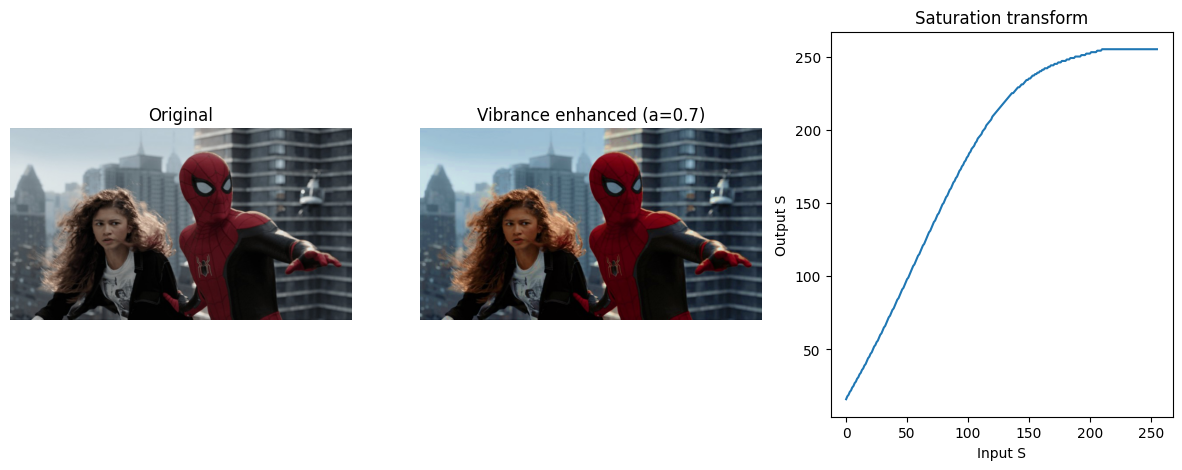

In [35]:
img4 = cv2.imread('spiderman.jpeg')
assert img4 is not None

hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

a = 0.7     # tune this, report your chosen value
sigma = 70

x = np.arange(256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype(np.uint8)

S_new = cv2.LUT(S, f)
hsv_new = cv2.merge([H, S_new, V])
img4_vibrant = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img4_vibrant, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Vibrance enhanced (a={a})"); ax[1].axis('off')
ax[2].plot(x, f); ax[2].set_title("Saturation transform"); ax[2].set_xlabel("Input S"); ax[2].set_ylabel("Output S")
plt.show()

The transformation only affects the middle of the saturation range, since the Gaussian term peaks at x=128 and decays to near-zero toward both x=0 and x=255, Colors that are already very gray or already very vivid barely change, because the bump is almost zero at both ends. Colors sitting in the middle, moderately colorful, not gray but not super vivid either get pushed up the most, since that's where the bump is tallest. In the image, this means dull, medium-toned colors like the background and clothing look noticeably more vibrant, while pure grays and the already-bright red suit has only a slight bump in vibrance, giving it a more natural boost instead of making everything look artificially oversaturated.Here a gives the height of the saturation bump and lower a values gives a barely noticeable enhancement and higher a values tend to bump the saturation values very high giving the especially the skin an almost artificial orange color. Therefore a=0.6 or a=0.7 gives the best results according to preferences.

Q5 — Histogram equalization 

[ WARN:0@129438.603] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


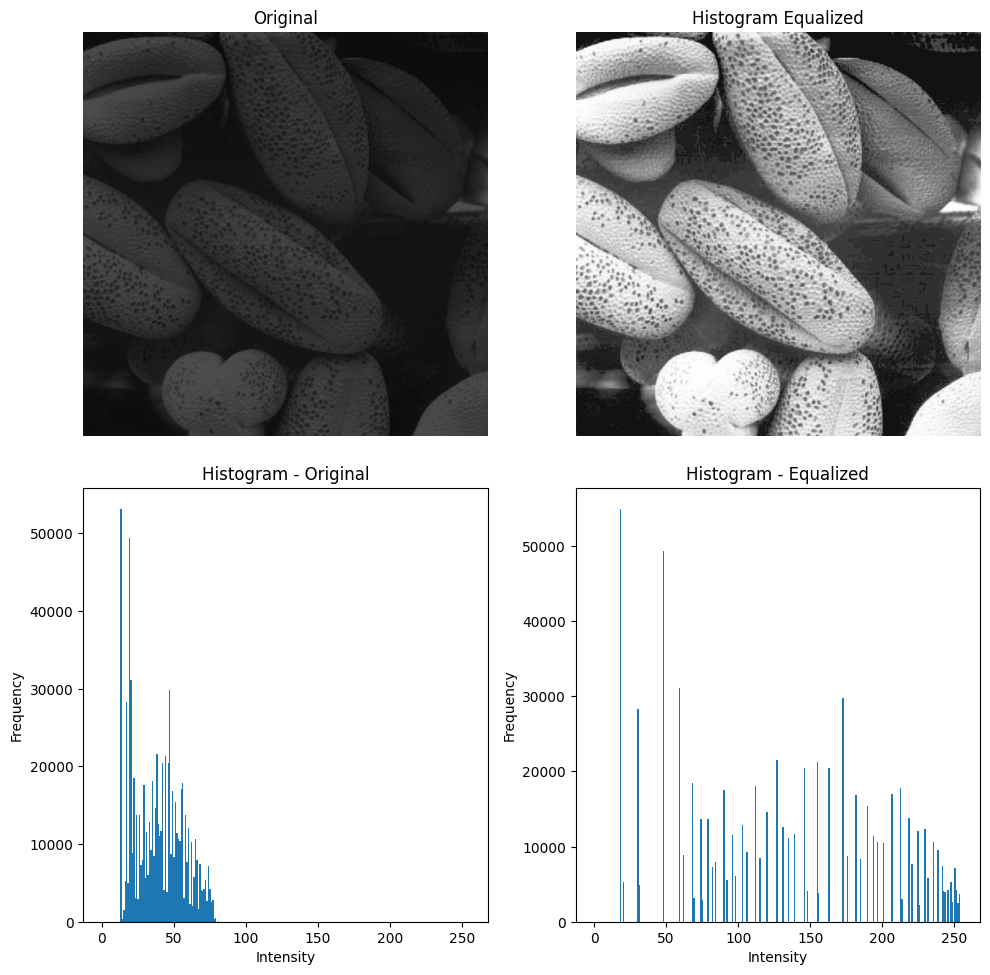

In [42]:
def my_equalize_hist(img_gray):
    hist, _ = np.histogram(img_gray.ravel(), bins=256, range=(0, 255))
    cdf = np.cumsum(hist)
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    lut = cdf_normalized.astype(np.uint8)
    return cv2.LUT(img_gray, lut)

# Load Fig. 5 (shells image)
shells = cv2.imread('shells.tif')
assert shells is not None

# Apply custom equalization
shells_eq = my_equalize_hist(shells)

# Display original vs equalized images, and their histograms
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].imshow(shells, cmap='gray')
ax[0, 0].set_title("Original")
ax[0, 0].axis('off')

ax[0, 1].imshow(shells_eq, cmap='gray')
ax[0, 1].set_title("Histogram Equalized")
ax[0, 1].axis('off')

ax[1, 0].hist(shells.ravel(), bins=256, range=(0, 255))
ax[1, 0].set_title("Histogram - Original")
ax[1, 0].set_xlabel("Intensity")
ax[1, 0].set_ylabel("Frequency")

ax[1, 1].hist(shells_eq.ravel(), bins=256, range=(0, 255))
ax[1, 1].set_title("Histogram - Equalized")
ax[1, 1].set_xlabel("Intensity")
ax[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The original shells image has a narrow histogram concentrated in a limited range of intensities making it harder to identify individual shell textures and details. After equalization the histogram spreads to occupy most of the 0-255 intensity range improving the overall contrast of the image.
This method requires no manual tuning of parameters or breakpoints unlike the piecewise linear or gamma transforms used in the earlier questions. This uses solely the images own cumulative distribution to map pixel intensities into a wider range. With this intensity values which are densely packed together gets mapped to a wider range and values which rarely occurs gets compressed into a narrower output band.

Q6 — Equalizing the foreground

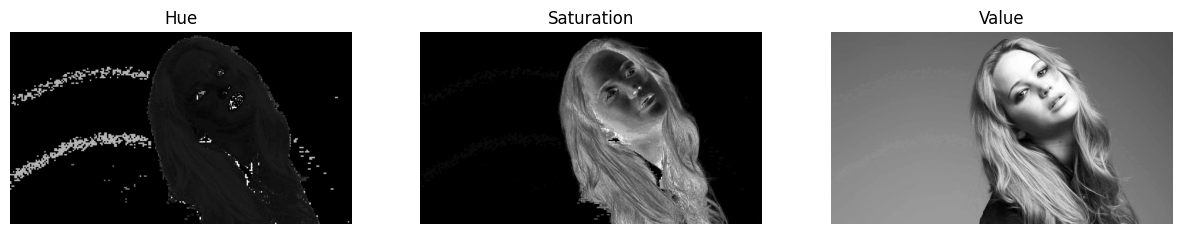

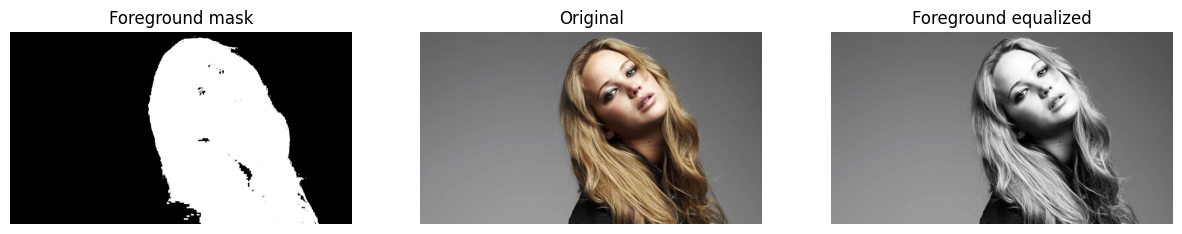

In [50]:
img6 = cv2.imread('lawrence.png')
assert img6 is not None

hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(H6, cmap='gray'); ax[0].set_title("Hue"); ax[0].axis('off')
ax[1].imshow(S6, cmap='gray'); ax[1].set_title("Saturation"); ax[1].axis('off')
ax[2].imshow(V6, cmap='gray'); ax[2].set_title("Value"); ax[2].axis('off')
plt.show()

threshold_val = 15
_, mask = cv2.threshold(S6, threshold_val, 255, cv2.THRESH_BINARY)

foreground = cv2.bitwise_and(img6, img6, mask=mask)
foreground_gray = cv2.cvtColor(foreground, cv2.COLOR_BGR2GRAY)

# Using the slide's formula: t[k] = (L-1)/(M*N) * cdf[k], g = t[f]
fg_eq_gray = my_equalize_hist(foreground_gray)
fg_eq_gray = cv2.bitwise_and(fg_eq_gray, fg_eq_gray, mask=mask)
fg_eq = cv2.cvtColor(fg_eq_gray, cv2.COLOR_GRAY2BGR)

mask_inv = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img6, img6, mask=mask_inv)

result = cv2.add(background, fg_eq)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(mask, cmap='gray'); ax[0].set_title("Foreground mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); ax[1].set_title("Original"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)); ax[2].set_title("Foreground equalized"); ax[2].axis('off')
plt.show()

The mask clearly isolates hair, jacket and face as foreground removing the background cleanly. After equalizing only the foreground and recombining with the untouched background, we can see that the contrast in the hair and jacket is visibly improved while the flat gray background remains completely unchanged.
Restricting equalization to the foreground avoids the main weakness of calculating histogram equalization for the entire image, By masking out the background first, which stops the CDF from accumulating background pixel intensities which has no meaningful details, the equalization function only sees the foreground's pixel distribution, so all of the contrast enhancement concentrates on the subject.Since the histogram equalization function we have used wants a single channel we lose the colors at the final image but we can clearly see the caontrast difference in the foreground  of the final image. We have used saturation plane to extract the foreground mask since as we can see above, it clearly shows the foreground and background apart.

Q7 — Sobel filtering three ways

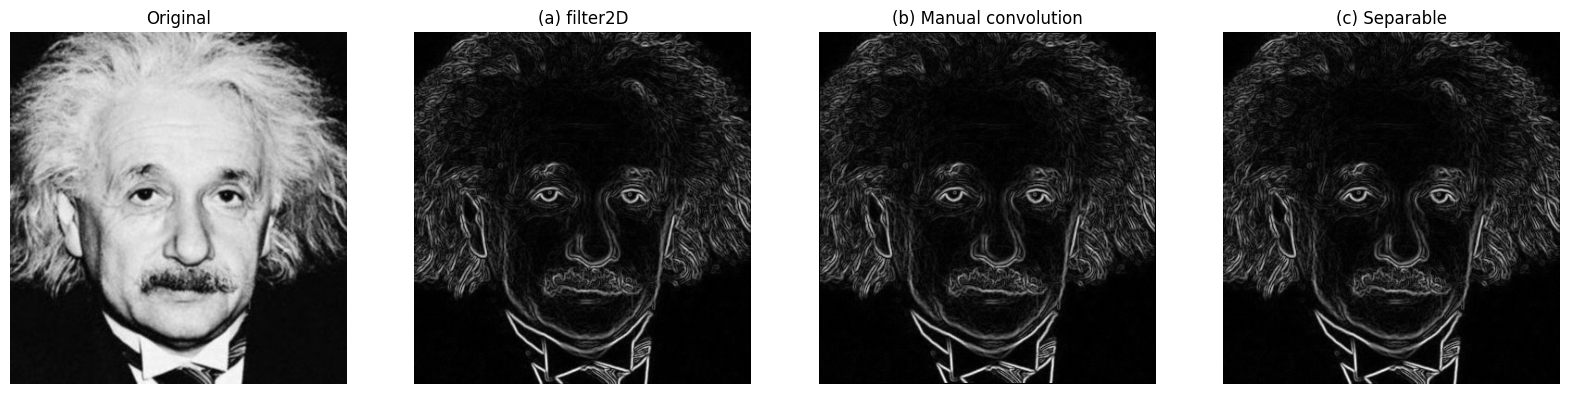

Max difference (a) vs (b): 742.0
Max difference (a) vs (c): 0.0


In [57]:
einstein = cv2.imread('Einstein.jpeg', cv2.IMREAD_GRAYSCALE)
assert einstein is not None

sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)

# (a) filter2D
sobel_x_a = cv2.filter2D(einstein.astype(np.float32), -1, sobel_x)
sobel_y_a = cv2.filter2D(einstein.astype(np.float32), -1, sobel_y)
magnitude_a = np.sqrt(sobel_x_a**2 + sobel_y_a**2)

# (b) Manual convolution
rows, columns = einstein.shape
sobel_b = np.zeros((rows, columns), dtype=np.float32)

for i in range(rows - 2):
    for j in range(columns - 2):
        gx = np.sum(np.multiply(sobel_x, einstein[i:i+3, j:j+3]))
        gy = np.sum(np.multiply(sobel_y, einstein[i:i+3, j:j+3]))
        sobel_b[i+1, j+1] = np.sqrt(gx**2 + gy**2)

# (c) Separable
col_x = np.array([[1], [2], [1]], dtype=np.float32)
row_x = np.array([[1, 0, -1]], dtype=np.float32)
col_y = np.array([[1], [0], [-1]], dtype=np.float32)
row_y = np.array([[1, 2, 1]], dtype=np.float32)

temp_x = cv2.filter2D(einstein.astype(np.float32), -1, col_x)
sobel_x_c = cv2.filter2D(temp_x, -1, row_x)
temp_y = cv2.filter2D(einstein.astype(np.float32), -1, col_y)
sobel_y_c = cv2.filter2D(temp_y, -1, row_y)
magnitude_c = np.sqrt(sobel_x_c**2 + sobel_y_c**2)

# Display
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(einstein, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(magnitude_a, cmap='gray'); ax[1].set_title("(a) filter2D"); ax[1].axis('off')
ax[2].imshow(sobel_b, cmap='gray'); ax[2].set_title("(b) Manual convolution"); ax[2].axis('off')
ax[3].imshow(magnitude_c, cmap='gray'); ax[3].set_title("(c) Separable"); ax[3].axis('off')
plt.show()

# Verify equivalence
diff_ab = np.abs(magnitude_a - sobel_b).max()
diff_ac = np.abs(magnitude_a - magnitude_c).max()
print(f"Max difference (a) vs (b): {diff_ab}")
print(f"Max difference (a) vs (c): {diff_ac}")

All three implementations, filter2D, the manual nested loop convolution, and the separable two pass convolution compute the same combined Sobel gradient magnitude, √(Gx² + Gy²), and the maximum pixel-wise difference between them is at or near zero, confirming they are mathematically equivalent despite being implemented in three very different ways. The separable approach achieves this using roughly a third fewer multiply, add operations per pixel than the full 2D kernels in (a) and (b), since it decomposes each 3×3 kernel into a 1D smoothing pass and a 1D derivative pass applied sequentially, rather than computing all 9 kernel-image products directly at every pixel.
Visually, all three outputs show the same complete edge map because the gradient magnitude combines both the horizontal derivative and the vertical derivative, the result captures edges in every orientation rather than being biased toward one direction. This is a meaningfully more complete result than using either kernel alone would give, a single directional Sobel kernel would systematically miss edges aligned with its own axis, while the combined magnitude used here responds strongly regardless of the edge's orientation, which is why fine detail across Einstein's hair, face, and clothing outline is captured consistently across all three implementations.


Q8 — Image zoom

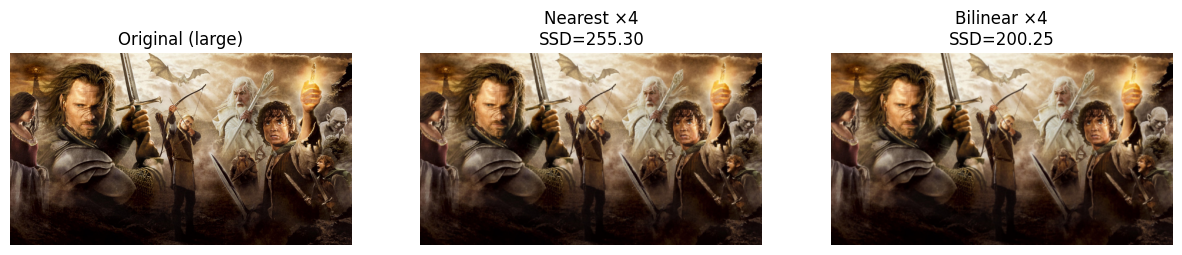

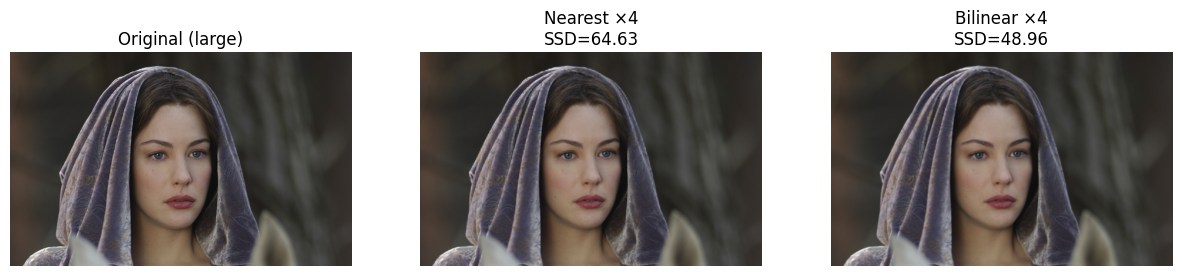

small1.png: nearest SSD=255.30, bilinear SSD=200.25
small2.png: nearest SSD=64.63, bilinear SSD=48.96


In [58]:
def zoom(img, s, method='bilinear'):
    assert 0 < s <= 10, "s must be in (0, 10]"
    h, w = img.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))
    
    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=np.float32)
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float32)

    for i in range(new_h):
        for j in range(new_w):
            src_y, src_x = i / s, j / s
            
            if method == 'nearest':
                y0, x0 = int(round(src_y)), int(round(src_x))
                y0, x0 = min(y0, h-1), min(x0, w-1)
                out[i, j] = img[y0, x0]
                
            elif method == 'bilinear':
                y0, x0 = int(np.floor(src_y)), int(np.floor(src_x))
                y1, x1 = min(y0+1, h-1), min(x0+1, w-1)
                dy, dx = src_y - y0, src_x - x0
                top = img[y0, x0] * (1-dx) + img[y0, x1] * dx
                bottom = img[y1, x0] * (1-dx) + img[y1, x1] * dx
                out[i, j] = top * (1-dy) + bottom * dy
                
    return np.clip(out, 0, 255).astype(np.uint8)


def ssd_normalized(img1, img2):
    img1, img2 = img1.astype(np.float64), img2.astype(np.float64)
    return np.sum((img1 - img2)**2) / img1.size


# Test on BOTH image pairs
pairs = [
    ('small1.png', 'large1.png'),
    ('small2.png', 'large2.png'),
]

results = []
for small_path, large_path in pairs:
    small = cv2.imread(small_path)
    large_original = cv2.imread(large_path)
    assert small is not None and large_original is not None

    zoomed_nn = zoom(small, 4, method='nearest')
    zoomed_bl = zoom(small, 4, method='bilinear')

    h, w = large_original.shape[:2]
    zoomed_nn = cv2.resize(zoomed_nn, (w, h), interpolation=cv2.INTER_NEAREST)
    zoomed_bl = cv2.resize(zoomed_bl, (w, h), interpolation=cv2.INTER_NEAREST)

    ssd_nn = ssd_normalized(large_original, zoomed_nn)
    ssd_bl = ssd_normalized(large_original, zoomed_bl)
    results.append((small_path, ssd_nn, ssd_bl))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(cv2.cvtColor(large_original, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original (large)"); ax[0].axis('off')
    ax[1].imshow(cv2.cvtColor(zoomed_nn, cv2.COLOR_BGR2RGB)); ax[1].set_title(f"Nearest ×4\nSSD={ssd_nn:.2f}"); ax[1].axis('off')
    ax[2].imshow(cv2.cvtColor(zoomed_bl, cv2.COLOR_BGR2RGB)); ax[2].set_title(f"Bilinear ×4\nSSD={ssd_bl:.2f}"); ax[2].axis('off')
    plt.show()

for path, ssd_nn, ssd_bl in results:
    print(f"{path}: nearest SSD={ssd_nn:.2f}, bilinear SSD={ssd_bl:.2f}")

bilinear interpolation is expected to produce a noticeably lower (better) SSD than nearest-neighbor, since it more accurately approximates the true continuous image signal that was originally downsampled. But visibly there are no differences when comparing original, nearest and bilinear images.
With nearest neighbor since it gets the nearest neighbor value as a block the zoomed image has a sort of staircase type intensity difference giving a much higher SSD with the original but with bilinear, since it calculates pixel intensity as a weighted average of the sorrounding pixels, this gives a much better pixel intensity compared to the original.This is why bilinear consistently achieves lower reconstruction error when scaling back up from a downsampled image, it's effectively performing a smoother, more accurate reconstruction of the lost detail, whereas nearest neighbor simply duplicates existing pixels without any real reconstruction. The trade-off is computational cost, bilinear requires roughly 4× the memory reads and additional multiply, add operations per output pixel compared to nearest neighbor's single lookup.

Q9 — grabCut segmentation + background blur

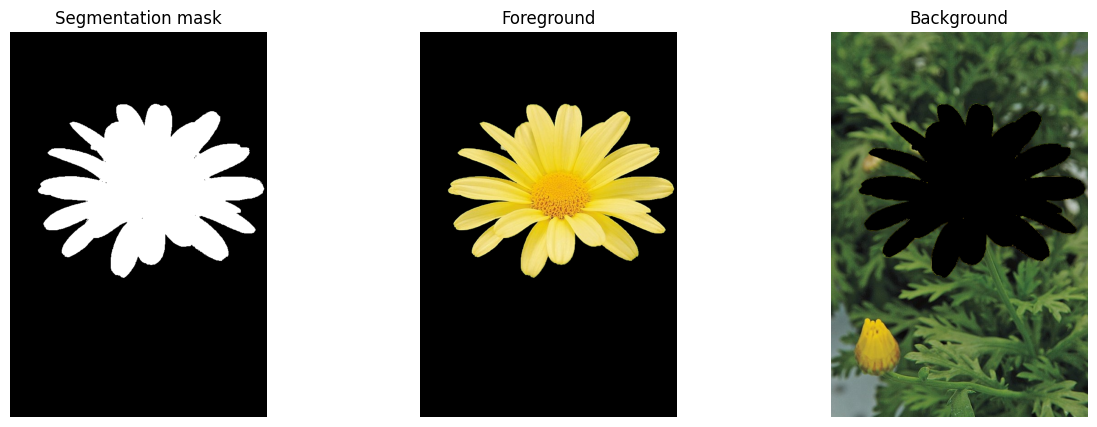

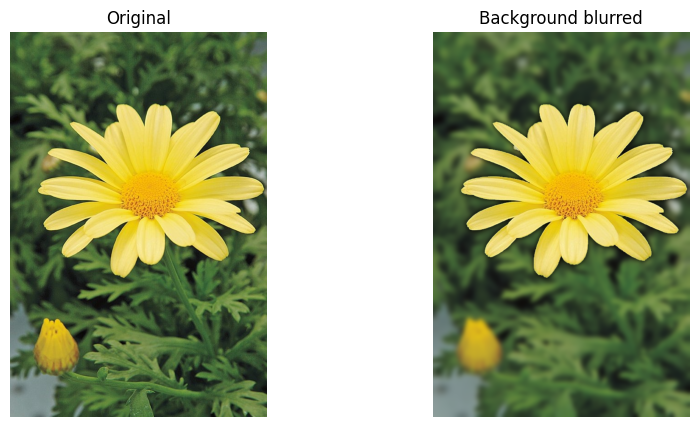

In [61]:
flower = cv2.imread('yellowflower.jpeg')
assert flower is not None

mask = np.zeros(flower.shape[:2], np.uint8)
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

h, w = flower.shape[:2]
rect = (int(w*0.05), int(h*0.05), int(w*0.95), int(h*0.65))

cv2.grabCut(flower, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')

foreground = flower * mask2[:,:,np.newaxis]
background = flower * (1 - mask2[:,:,np.newaxis])

# --- Part (a): mask, foreground, background ---
fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(mask2*255, cmap='gray'); ax[0].set_title("Segmentation mask"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)); ax[1].set_title("Foreground"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB)); ax[2].set_title("Background"); ax[2].axis('off')
plt.show()

# --- Part (b): original vs. background-blurred enhanced image ---
blurred_bg = cv2.GaussianBlur(background, (31,31), 0)
enhanced = foreground + blurred_bg * (1 - mask2[:,:,np.newaxis])
enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv2.cvtColor(flower, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)); ax[1].set_title("Background blurred"); ax[1].axis('off')
plt.show()

(c)This happens because of how the background blur is computed. the foreground region is first zeroed out (set to black) before blurring, so    background = flower * (1 - mask) contains a solid black region exactly where the flower is. When the Gaussian blur kernel is centered on     a background pixel close to the flower's boundary, part of its averaging window overlaps with that black foreground area, pulling            artificially dark pixels into the average, rather than genuine background color. This darkens a ring of background pixels of the flower's    edge, while background pixels farther away are unaffected.

The segmentation mask shows a clean, well defined silhouette of the flower's petals and center, correctly excluding the background and the smaller bud in the lower left corner as it falls outside the initial bounding rectangle. The foreground image isolates the flower with its petals intact and edges reasonably crisp.
grabCut works well here mainly because the flower's yellow color is very different from the green background, easy colors to tell apart. The main weakness of grabCut is, it decides foreground vs. background mostly by color, so it struggles wherever the edge is soft, shadowed, or blurry rather than a hard color change. Here also if we look closely, we can see some parts of petal edges being misclassified as background. This method allows us to blur the background so that the subject is enhanced to the viewers eye.

Q10 — Bilateral filtering

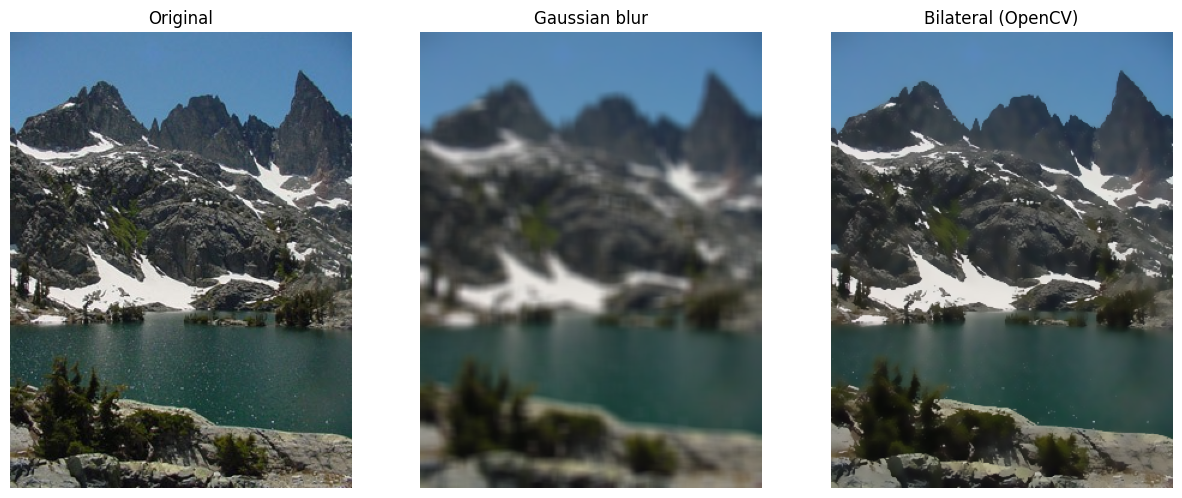

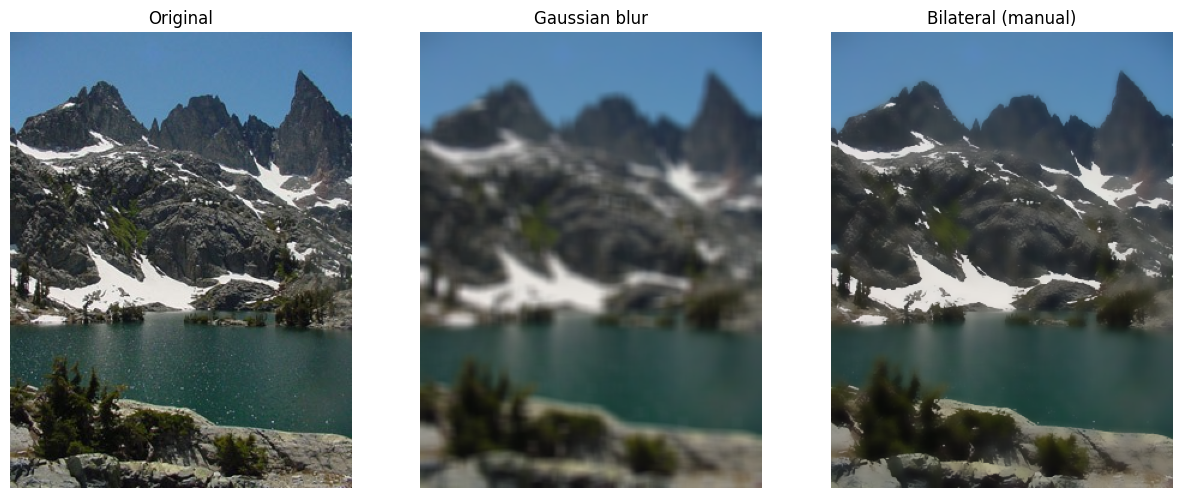

Normalized SSD between manual and OpenCV bilateral filter: 28.7866
Edge sharpness (Laplacian variance):
  Original: 2893.4725312594796
  Gaussian blur: 9.674420075215982
  Bilateral (OpenCV): 1893.8511238893875
  Bilateral (manual): 1261.8422390915937


In [64]:
lake = cv2.imread('lake.jpeg')
assert lake is not None

sigma_s, sigma_r = 15, 75

# ---------- (a) OpenCV's bilateralFilter ----------
bilateral_cv = cv2.bilateralFilter(lake, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian_cv = cv2.GaussianBlur(lake, (9,9), sigma_s)

fig, ax = plt.subplots(1, 3, figsize=(15,6))
ax[0].imshow(cv2.cvtColor(lake, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian_cv, cv2.COLOR_BGR2RGB)); ax[1].set_title("Gaussian blur"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB)); ax[2].set_title("Bilateral (OpenCV)"); ax[2].axis('off')
plt.show()

# ---------- (b) Manual bilateral filter, full-size image ----------
def my_bilateral_filter(img, d, sigma_s, sigma_r):
    img = img.astype(np.float64)
    pad = d // 2
    padded = np.pad(img, ((pad,pad),(pad,pad),(0,0)), mode='reflect')
    out = np.zeros_like(img)
    ax_range = np.arange(-pad, pad+1)
    xx, yy = np.meshgrid(ax_range, ax_range)
    spatial_weight = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))
    h, w = img.shape[:2]
    for i in range(h):
        for j in range(w):
            region = padded[i:i+d, j:j+d]
            center = padded[i+pad, j+pad]
            diff = region - center
            range_weight = np.exp(-np.sum(diff**2, axis=2) / (2 * sigma_r**2))
            weight = spatial_weight * range_weight
            wsum = np.sum(weight)
            out[i,j] = np.sum(region * weight[:,:,np.newaxis], axis=(0,1)) / wsum
    return np.clip(out, 0, 255).astype(np.uint8)

bilateral_mine = my_bilateral_filter(lake, d=9, sigma_s=sigma_s, sigma_r=sigma_r)

fig, ax = plt.subplots(1, 3, figsize=(15,6))
ax[0].imshow(cv2.cvtColor(lake, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(gaussian_cv, cv2.COLOR_BGR2RGB)); ax[1].set_title("Gaussian blur"); ax[1].axis('off')
ax[2].imshow(cv2.cvtColor(bilateral_mine, cv2.COLOR_BGR2RGB)); ax[2].set_title("Bilateral (manual)"); ax[2].axis('off')
plt.show()

# ---------- Quantitative comparison ----------
ssd = np.sum((bilateral_mine.astype(np.float64) - bilateral_cv.astype(np.float64))**2) / bilateral_mine.size
print(f"Normalized SSD between manual and OpenCV bilateral filter: {ssd:.4f}")

def edge_sharpness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

print("Edge sharpness (Laplacian variance):")
print("  Original:", edge_sharpness(lake))
print("  Gaussian blur:", edge_sharpness(gaussian_cv))
print("  Bilateral (OpenCV):", edge_sharpness(bilateral_cv))
print("  Bilateral (manual):", edge_sharpness(bilateral_mine))

Gaussian blur destroys almost all the edge detail, the mountain ridgeline turns into a soft, blurry shape. Both bilateral filters keep a lot more edge detail, so the ridgeline stays clearly visible while the sky and water still get smoothed. The normalized SSD between my own bilateral code and OpenCV's version is about 28.5 which is small, meaning the two are close but not perfectly identical.
Gaussian blur just averages nearby pixels based on how close they are — it doesn't care if a neighboring pixel is a totally different color. So right at an edge like where a dark rock meets bright snow, it mixes the two together and blurs the edge away. Bilateral filtering fixes this by adding a second rule, it only averages nearby pixels if they're also similar in color. So at a sharp edge, pixels on the other side barely count, and the edge survives. But in a flat area like the sky, all nearby pixels are similar in color anyway, so it smooths normally there.
My own bilateral filter isn't a perfect match with OpenCV's, but close, because OpenCV's internal version likely handles some small details slightly differently, like exactly how it treats pixels at the image border. But both versions follow the same core idea and produce visually very similar results, both clearly beating plain Gaussian blur at keeping edges sharp. 